# Análisis de Inscripciones Educativas

## 1. Instalación de dependencias

Dependencias necesarias para el analisis:
- Sqlalchemy
- Pandas
- Pymysql
- matplotlib

In [25]:
%pip install sqlalchemy pymysql matplotlib pandas --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Conexión a MariaDB

In [7]:
from sqlalchemy import create_engine
import pandas as pd

#Parametros para la conexión a la base de datos
DB_USER = "root"
DB_PASSWORD = "" 
DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_NAME = "inscripciones_db"

# Cadena de conexión
connection_url = (
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    "?charset=utf8mb4"
)

# Creación de motor de conexión a la base de datos
engine = create_engine(connection_url, echo=False)

## 3. Carga de tablas en DataFrames

In [8]:
with engine.connect() as conn:
    df_alumnos = pd.read_sql("SELECT * FROM alumnos", conn, index_col="id")
    df_programas = pd.read_sql("SELECT * FROM programas", conn, index_col="id")
    df_inscripciones = pd.read_sql("SELECT * FROM inscripciones",    conn, index_col="id")
    df_historial_status = pd.read_sql("SELECT * FROM historial_status", conn, index_col="id")


print("── alumnos ──────────────────────────────────────────")
display(df_alumnos)

print("\n── programas ────────────────────────────────────────")
display(df_programas)

print("\n── inscripciones ────────────────────────────────────")
display(df_inscripciones)

print("\n── historial_status ─────────────────────────────────")
display(df_historial_status)


── alumnos ──────────────────────────────────────────


,nombre,empresa,fecha_ingreso
id,,,
1,Luis Cruz,Soriana,2024-02-26
2,Andrés Ramírez,Coppel,2022-10-04
3,Daniela Ortiz,Soriana,2017-10-02
4,Luis Reyes,Soriana,2015-06-06
5,Sofía Hernández,Soriana,2017-03-31
6,Paola Mendoza,Bayer,2023-03-28
7,Gabriela Cruz,Soriana,2024-03-30
8,Gabriela Morales,Soriana,2018-07-05
9,Paola López,Soriana,2017-06-01



── programas ────────────────────────────────────────


,nombre,descripcion
id,,
1,Lic. Negocios,Licenciatura enfocada en gestión y desarrollo ...
2,Lic. Logística,Licenciatura en administración de cadenas de s...
3,Lic. Administración,Licenciatura en administración de organizacion...
4,Bachillerato Ejecutivo,Bachillerato intensivo para adultos trabajador...
5,Maestría en Dirección,Posgrado orientado al liderazgo estratégico y ...



── inscripciones ────────────────────────────────────


,id_alumno,id_programa,estatus
id,,,
1,1,1,activo
2,2,3,suspendido
3,3,2,egresado
4,4,2,egresado
5,5,2,baja_programa
6,6,4,baja_programa
7,7,1,baja_empresa
8,8,1,baja_empresa
9,9,2,egresado



── historial_status ─────────────────────────────────


,id_inscripcion,estatus_anterior,estatus_nuevo,fecha_cambio,motivo
id,,,,,
1,1,None,inscrito,2024-02-27,Inscripción inicial al programa
2,1,inscrito,activo,2024-03-28,Inicio de actividades académicas
3,2,None,inscrito,2022-10-05,Inscripción inicial al programa
4,2,inscrito,activo,2022-11-03,Inicio de actividades académicas
5,2,activo,suspendido,2023-11-25,Adeudo pendiente de pago
6,3,None,inscrito,2017-10-03,Inscripción inicial al programa
7,3,inscrito,activo,2017-11-01,Inicio de actividades académicas
8,3,activo,egresado,2018-01-12,Cumplimiento de créditos requeridos
9,5,None,inscrito,2017-04-01,Inscripción inicial al programa


# 4. Análisis de datos

## 4.1 Distribución de estatus actual por programa (groupby o tabla pivot)

In [14]:
# Join a programas para obtener el nombre del programa
df_insc_prog = df_inscripciones.join(
    df_programas[["nombre"]].rename(columns={"nombre": "programa"}),
    on="id_programa"
)

print("── Lista de inscripciones ────────────────────────")
display(df_insc_prog)

# Tabla pivote para obtener la distribución de estatus actual por programa

## Status order para el orden de los estatus
STATUS_ORDER = ["inscrito", "activo", "suspendido",
                "baja_empresa", "baja_programa", "reingreso", "egresado"]

pivot = pd.crosstab(df_insc_prog["programa"], df_insc_prog["estatus"])
pivot["TOTAL"] = pivot.sum(axis=1)

print("Distribución de estatus actual por programa\n")
display(pivot)

── Lista de inscripciones ────────────────────────


,id_alumno,id_programa,estatus,programa
id,,,,
1,1,1,activo,Lic. Negocios
2,2,3,suspendido,Lic. Administración
3,3,2,egresado,Lic. Logística
4,4,2,egresado,Lic. Logística
5,5,2,baja_programa,Lic. Logística
6,6,4,baja_programa,Bachillerato Ejecutivo
7,7,1,baja_empresa,Lic. Negocios
8,8,1,baja_empresa,Lic. Negocios
9,9,2,egresado,Lic. Logística


Distribución de estatus actual por programa



estatus,activo,baja_empresa,baja_programa,egresado,reingreso,suspendido,TOTAL
programa,,,,,,,
Bachillerato Ejecutivo,0,0,1,0,0,0,1
Lic. Administración,0,0,0,0,1,1,2
Lic. Logística,0,0,1,4,0,0,5
Lic. Negocios,1,2,0,0,0,0,3
Maestría en Dirección,0,0,0,0,0,1,1


# 4.2 Evolución mensual de bajas vs. alumnos activos (línea de tiempo)

In [ ]:
#Tipo de bajas para el filtro
BAJAS = {"baja_empresa", "baja_programa"}

#DataFrame con los datos de historial de estatus filtrados por estatus_nuevo
df_hist = df_historial_status.query("estatus_nuevo in ('activo', 'baja_empresa', 'baja_programa')").copy()

#Creación de las columnas mes y tipo
df_hist["mes"] = pd.to_datetime(df_hist["fecha_cambio"]).dt.to_period("M")
df_hist["tipo"] = df_hist["estatus_nuevo"].map(lambda s: "baja" if s in BAJAS else "activo")

#Creación de la tabla pivot
monthly = pd.crosstab(df_hist["mes"], df_hist["tipo"])
monthly.index = monthly.index.to_timestamp()

display(monthly)


tipo,activo,baja
mes,,
2017-04-01,1,0
2017-09-01,0,1
2017-11-01,2,0
2018-08-01,1,0
2018-10-01,0,2
2022-06-01,1,0
2022-11-01,1,0
2023-04-01,1,0
2024-03-01,1,1


## 4.3 Tasa de activos por programa: activos / total inscritos históricos

In [22]:
# Agregar nombre de programa a inscripciones
df_ip = df_inscripciones.copy()
df_ip["programa"] = df_ip["id_programa"].map(df_programas["nombre"])

# Total histórico de inscritos por programa
total = df_ip.groupby("programa")["id_alumno"].count().rename("total_inscritos")

# Alumnos activos por programa
activos = df_ip[df_ip["estatus"] == "activo"].groupby("programa")["id_alumno"].count().rename("activos")

# Tabla resumen con tasa
df_tasa = pd.concat([total, activos], axis=1).fillna(0)
df_tasa["activos"] = df_tasa["activos"].astype(int)
df_tasa["tasa_activos_pct"] = (df_tasa["activos"] / df_tasa["total_inscritos"] * 100).round(1)
df_tasa = df_tasa.sort_values("tasa_activos_pct", ascending=False)

display(df_tasa)

,total_inscritos,activos,tasa_activos_pct
programa,,,
Lic. Negocios,3,1,33.3
Bachillerato Ejecutivo,1,0,0.0
Lic. Administración,2,0,0.0
Lic. Logística,5,0,0.0
Maestría en Dirección,1,0,0.0


## 4.4 Identificar el motivo de baja más frecuente (análisis de la columna motivo de la tabla historial_estatus que tú generaste

In [23]:
BAJAS = ["baja_empresa", "baja_programa"]

# Filtrar solo registros de baja
df_bajas = df_historial_status[df_historial_status["estatus_nuevo"].isin(BAJAS)].copy()

# Conteo de motivos
df_motivos = df_bajas["motivo"].value_counts().rename_axis("motivo").reset_index(name="frecuencia")

# Porcentaje
df_motivos["pct"] = (df_motivos["frecuencia"] / df_motivos["frecuencia"].sum() * 100).round(1)

display(df_motivos)

# Motivo más frecuente
print(f"\nMotivo más frecuente: '{df_motivos.iloc[0]['motivo']}' ({df_motivos.iloc[0]['frecuencia']} vez/veces)")

,motivo,frecuencia,pct
0,Carga de trabajo elevada en empresa,1,20.0
1,Motivos personales,1,20.0
2,Recorte de personal en Soriana,1,20.0
3,Reestructura organizacional,1,20.0
4,Término de contrato con Alpura,1,20.0



Motivo más frecuente: 'Carga de trabajo elevada en empresa' (1 vez/veces)


# 5. Visualizaciones

## 5.1 Gráfica de barras apiladas: estatus por programa

<Axes: title={'center': 'Estatus actual por programa'}, ylabel='Número de alumnos'>

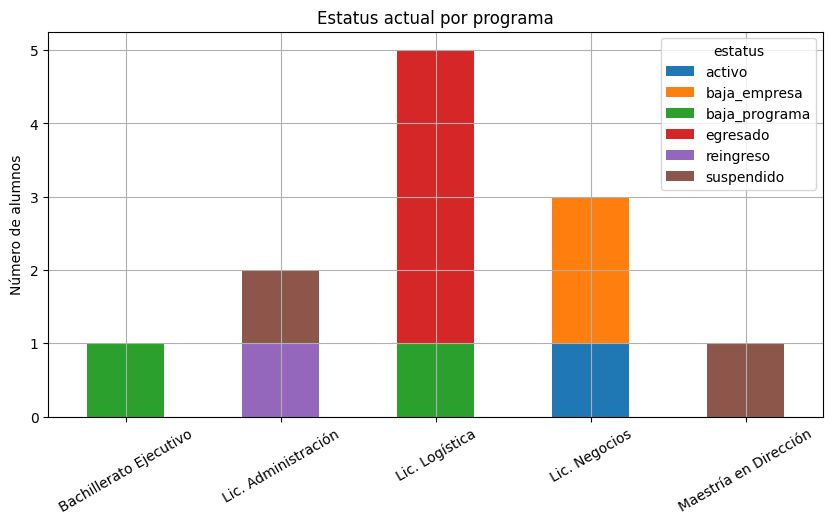

In [ ]:
# Reutilización de la tabla pivote de la seccion 4.1 (sin la columna TOTAL para graficar)
pivot_graf = pivot.drop(columns="TOTAL")

pivot_graf.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    title="Estatus actual por programa",
    ylabel="Número de alumnos",
    xlabel="",
    rot=30,
    grid=True,
)

## 5.2 Gráfica de línea: altas y bajas por mes

<Axes: title={'center': 'Altas y bajas por mes'}, xlabel='Mes', ylabel='Número de alumnos'>

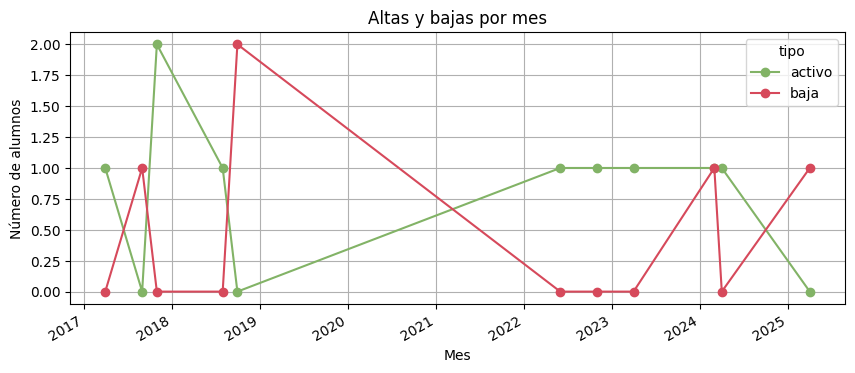

In [27]:
# Reutiliza el DataFrame monthly de la sección 4.2
monthly.plot(
    kind="line",
    figsize=(10, 4),
    marker="o",
    color={"activo": "#82B366", "baja": "#D6495B"},
    title="Altas y bajas por mes",
    ylabel="Número de alumnos",
    xlabel="Mes",
    grid=True,
)